In [ ]:
# Random Forests
# for supervised machine learning, where there is a labeled target variable.
# can be used for solving regression (numeric target variable) and classification (categorical target variable) problems.
# are an ensemble method, meaning they combine predictions from other models.
# Each of the smaller models in the random forest ensemble is a decision tree.

In [ ]:
# IMPORTS

import pandas as pd
import numpy as np
import csv
from google.colab import files


# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay

# Tree Visualization
from sklearn.tree import export_graphviz
import graphviz

# Hyperparameter tuning distributions
from scipy.stats import randint

In [ ]:
# UPLOAD CSV
uploaded = files.upload()

Saving bank-data.csv to bank-data (3).csv


In [ ]:
def repair_csv(path):
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # Fix HTML-escaped double quotes
            line = line.replace("&quot;", '"')

            # Remove outer quotes
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]

            # Replace doubled quotes
            line = line.replace('""', '"')

            # Split using CSV parser
            row = next(csv.reader([line], delimiter=";", quotechar='"'))
            rows.append(row)

    return pd.DataFrame(rows[1:], columns=rows[0])

bank_data = repair_csv("bank-data.csv")
bank_data.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.2,-42,4.191,5195.8,no
5,32,services,single,university.degree,no,no,no,cellular,sep,thu,...,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no
6,32,admin.,single,university.degree,no,yes,no,cellular,sep,mon,...,4,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,no
7,41,entrepreneur,married,university.degree,unknown,yes,no,cellular,nov,mon,...,2,999,0,nonexistent,-0.1,93.2,-42,4.191,5195.8,no
8,31,services,divorced,professional.course,no,no,no,cellular,nov,tue,...,1,999,1,failure,-0.1,93.2,-42,4.153,5195.8,no
9,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191,no


In [ ]:
# SELECT ONLY RELEVANT COLUMNS

bank_data = bank_data[['age', 'default', 'cons.price.idx', 'cons.conf.idx', 'y']]

# Encode categorical
bank_data['default'] = bank_data['default'].map({'no': 0, 'yes': 1, 'unknown': 0})
bank_data['y'] = bank_data['y'].map({'no': 0, 'yes': 1})

# Drop missing target values
bank_data = bank_data.dropna(subset=['y'])

In [ ]:
# TRAIN-TEST SPLIT

X = bank_data.drop('y', axis=1)
y = bank_data['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# BASE RANDOM FOREST

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)
print("Initial Accuracy:", accuracy_score(y_test, y_pred))

Initial Accuracy: 0.8944174757281553


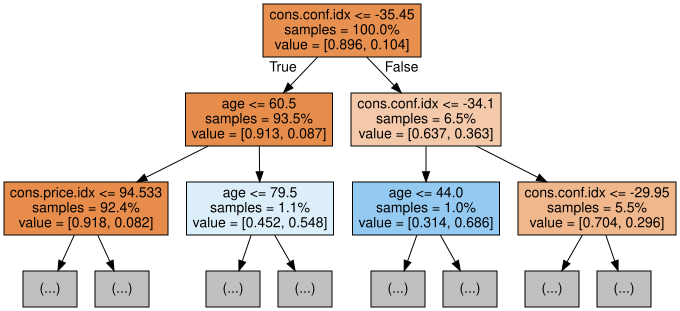

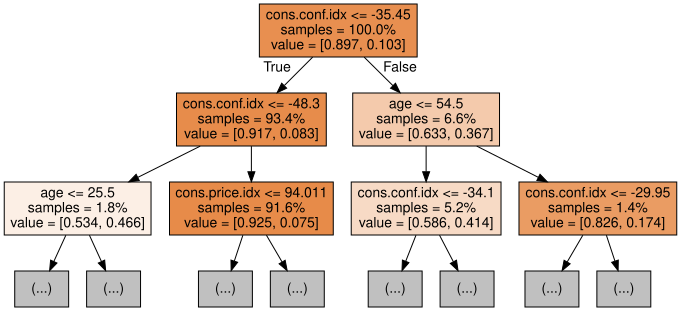

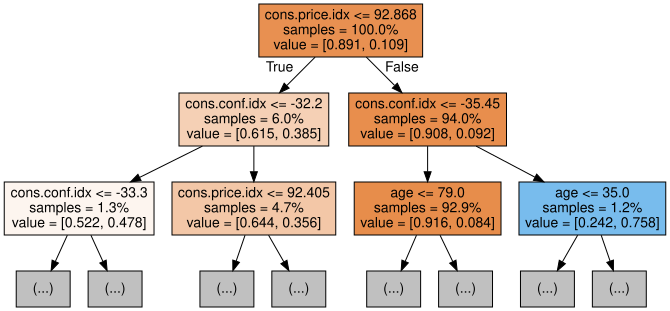

In [ ]:
# VISUALIZE FIRST 3 TREES (OPTIONAL)

for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(
        tree,
        feature_names=X_train.columns,
        filled=True,
        max_depth=2,
        impurity=False,
        proportion=True
    )
    display(graphviz.Source(dot_data))

In [ ]:
# HYPERPARAMETER TUNING

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)

print("Best parameters:", rand_search.best_params_)
print("Best CV Accuracy:", rand_search.best_score_)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 269}
Best CV Accuracy: 0.8910470409711685


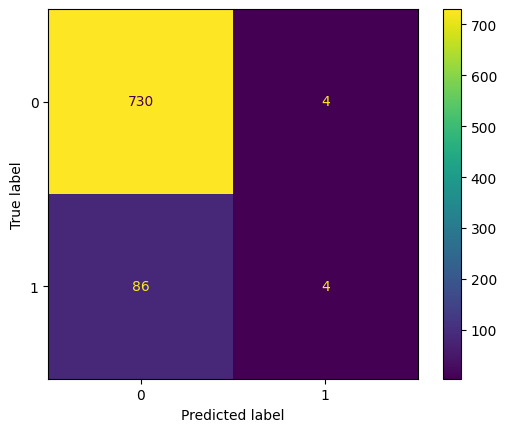

In [ ]:
# FINAL MODEL (BEST ESTIMATOR)

best_rf = rand_search.best_estimator_

y_pred = best_rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()



In [ ]:
# FINAL METRICS

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


Test Accuracy: 0.8907766990291263
Precision: 0.5
Recall: 0.044444444444444446


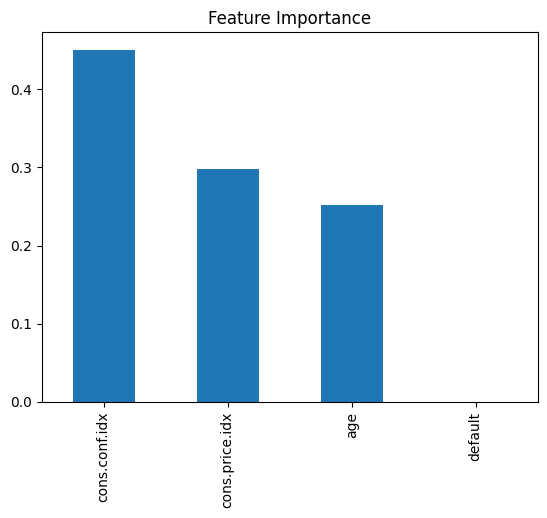

In [ ]:
# FEATURE IMPORTANCE

importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot.bar(title="Feature Importance");
